# Unit07 Example 03 — 化學反應平衡系統

本 Notebook 以 CO–H₂O 進料在高溫下的氣相多重反應平衡計算為案例，示範如何建立 **多變數聯立非線性方程式**，並使用 `scipy.optimize.fsolve()` 求解各成分的平衡組成。

## 目標
- 建立多重反應平衡方程式 $\mathbf{F}(\boldsymbol{\varepsilon}) = \mathbf{0}$（聯立非線性方程組）
- 繪製 $F_1 = 0$ 與 $F_2 = 0$ 的等高線圖，以圖形法確認解的位置
- 使用 `scipy.optimize.fsolve()` 求解平衡延伸量 $(\varepsilon_1, \varepsilon_2)$
- 分析起始猜測值對收斂結果的影響（敏感性分析）
- 驗證計算結果的物理合理性（莫耳分率加總、平衡常數代回）


---
### 0. 環境設定


In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit07_Example_03'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit07'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")


✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit07
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_03
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_03\figs


---
### 1. 載入套件


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import fsolve, root

# Matplotlib 設定
plt.rcParams['axes.unicode_minus'] = False

print("✓ 套件載入完成")
print(f"  numpy  : {np.__version__}")
import scipy
print(f"  scipy  : {scipy.__version__}")


✓ 套件載入完成
  numpy  : 1.23.5
  scipy  : 1.15.2


---
### 2. 問題設定：多重反應平衡參數


In [3]:
# ============================================================
# 系統：CO–H₂O 氣相多重反應平衡
# 條件：T = 700 K, P = 1 atm（理想氣體混合物）
# ============================================================
#
# 反應 R1: CO + H₂O ⇌ CO₂ + H₂     (水煤氣轉化, Δν = 0)
# 反應 R2: CO + 3H₂ ⇌ CH₄ + H₂O    (甲烷化反應, Δν = -2)
#
# 進料(mol): n_CO=2.0, n_H2O=1.0  (其餘成分初始量 = 0)
# ============================================================

# ── 平衡常數（以莫耳分率表示，P=1 atm）──────────────────────
K1 = 3.5    # R1: Kx1 = Kp1（Δν=0，與壓力無關）
K2 = 0.15   # R2: K2 = y_CH4·y_H2O/(y_CO·y_H2³)（P=1 atm，已含P補正）

# ── 進料組成 (mol) ─────────────────────────────────────────
n0 = {"CO": 2.0, "H2O": 1.0, "CO2": 0.0, "H2": 0.0, "CH4": 0.0}
n0_total = sum(n0.values())   # 3.0 mol

# ── 化學計量係數矩陣 ν[反應][成分] ─────────────────────────
# 成分順序: CO, H2O, CO2, H2, CH4
# R1: CO + H2O → CO2 + H2
# R2: CO + 3H2 → CH4 + H2O
nu = {
    "R1": {"CO": -1, "H2O": -1, "CO2": +1, "H2": +1,  "CH4":  0},
    "R2": {"CO": -1, "H2O": +1, "CO2":  0, "H2": -3,  "CH4": +1},
}

# ── 摩耳數方程式：n_i(ε₁, ε₂) = n0_i + ν_1i·ε₁ + ν_2i·ε₂ ───
# n_CO   = 2 - ε₁ - ε₂
# n_H2O  = 1 - ε₁ + ε₂
# n_CO2  = ε₁
# n_H2   = ε₁ - 3ε₂
# n_CH4  = ε₂
# n_total= 3 - 2ε₂  （Δn_R1=0, Δn_R2=-2）

species = list(n0.keys())   # ['CO', 'H2O', 'CO2', 'H2', 'CH4']

# ── 輸出問題概況 ─────────────────────────────────────────────
print("=" * 60)
print("  Gas-Phase Multi-Reaction Equilibrium  (T = 700 K, P = 1 atm)")
print("=" * 60)
print("  R1: CO + H2O  ⇌  CO2 + H2      K1 = 3.50  (Δν = 0)")
print("  R2: CO + 3H2  ⇌  CH4 + H2O     K2 = 0.15  (Δν = -2)")
print()
print("  Feed composition:")
print(f"    {'Species':<8}  {'n0 (mol)':>10}")
print("  " + "-" * 22)
for sp, val in n0.items():
    print(f"    {sp:<8}  {val:>10.2f}")
print(f"    {'Total':<8}  {n0_total:>10.2f}")
print("=" * 60)
print()
print("  Mole balance:")
print("    n_CO   = 2 - ε₁ - ε₂")
print("    n_H2O  = 1 - ε₁ + ε₂")
print("    n_CO2  = ε₁")
print("    n_H2   = ε₁ - 3ε₂")
print("    n_CH4  = ε₂")
print("    n_total= 3 - 2ε₂")
print()
print("  Physical constraints: ε₁ > 3ε₂,  0 < ε₁ < 1,  0 < ε₂ < ε₁/3")


  Gas-Phase Multi-Reaction Equilibrium  (T = 700 K, P = 1 atm)
  R1: CO + H2O  ⇌  CO2 + H2      K1 = 3.50  (Δν = 0)
  R2: CO + 3H2  ⇌  CH4 + H2O     K2 = 0.15  (Δν = -2)

  Feed composition:
    Species     n0 (mol)
  ----------------------
    CO              2.00
    H2O             1.00
    CO2             0.00
    H2              0.00
    CH4             0.00
    Total           3.00

  Mole balance:
    n_CO   = 2 - ε₁ - ε₂
    n_H2O  = 1 - ε₁ + ε₂
    n_CO2  = ε₁
    n_H2   = ε₁ - 3ε₂
    n_CH4  = ε₂
    n_total= 3 - 2ε₂

  Physical constraints: ε₁ > 3ε₂,  0 < ε₁ < 1,  0 < ε₂ < ε₁/3


---
### 3. 函數定義


In [4]:
def moles(eps1, eps2):
    """
    計算各成分摩耳數
    eps1, eps2 : 反應延伸量 (extent of reaction, mol)
    回傳 dict: {species: n_i}
    """
    n = {
        "CO":  2.0 - eps1 - eps2,
        "H2O": 1.0 - eps1 + eps2,
        "CO2": eps1,
        "H2":  eps1 - 3.0*eps2,
        "CH4": eps2,
    }
    return n


def mole_fractions(eps1, eps2):
    """計算各成分莫耳分率"""
    n = moles(eps1, eps2)
    n_total = sum(n.values())
    y = {sp: ni / n_total for sp, ni in n.items()}
    return y, n_total


def F_eq(eps_vec):
    """
    平衡方程組 F(ε₁, ε₂) = 0  （供 fsolve 使用）

    F1 = K1 - y_CO2 * y_H2 / (y_CO * y_H2O) = 0
    F2 = K2 - y_CH4 * y_H2O / (y_CO * y_H2^3) = 0
    """
    eps1, eps2 = eps_vec
    y, _ = mole_fractions(eps1, eps2)
    F1 = K1 - y["CO2"] * y["H2"] / (y["CO"] * y["H2O"])
    F2 = K2 - y["CH4"] * y["H2O"] / (y["CO"] * y["H2"]**3)
    return [F1, F2]


# ── 邊界驗證 ──────────────────────────────────────────────────
# 在純進料點（ε₁=0, ε₂=0）時，Kx1=y_CO2·y_H2/(y_CO·y_H2O) 應趨近於 0
# 表示方程式需向正方向前進（K1>0 意味平衡向右）
# 注意: ε₁=ε₂=0 使 y_CO2=0, y_H2=0 → F1 = K1 - 0 = K1 > 0 (需要延伸)
# ε₁=ε₂=0 也使 y_CH4=0 → F2 = K2 - 0 = K2 > 0 (兩個反應都需向右前進)

print("Function definitions OK.")
print()
print("─" * 52)
print("  Boundary check at feed (ε₁=0, ε₂=0):")
print("  (both K expressions = 0 → reaction must proceed forward)")

# 測試合理猜測值
eps1_test, eps2_test = 0.80, 0.05
y_test, _ = mole_fractions(eps1_test, eps2_test)
print()
print(f"  Test at (ε₁={eps1_test}, ε₂={eps2_test}):")
for sp, yi in y_test.items():
    print(f"    y_{sp:<5} = {yi:.4f}")
print(f"  F(ε) = {F_eq([eps1_test, eps2_test])}")
print("─" * 52)


Function definitions OK.

────────────────────────────────────────────────────
  Boundary check at feed (ε₁=0, ε₂=0):
  (both K expressions = 0 → reaction must proceed forward)

  Test at (ε₁=0.8, ε₂=0.05):
    y_CO    = 0.3966
    y_H2O   = 0.0862
    y_CO2   = 0.2759
    y_H2    = 0.2241
    y_CH4   = 0.0172
  F(ε) = [1.6913043478260865, -0.18286497397637083]
────────────────────────────────────────────────────


---
### 4. 圖形分析：等高線法尋找根


✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_03\figs\fig_01_contour.png


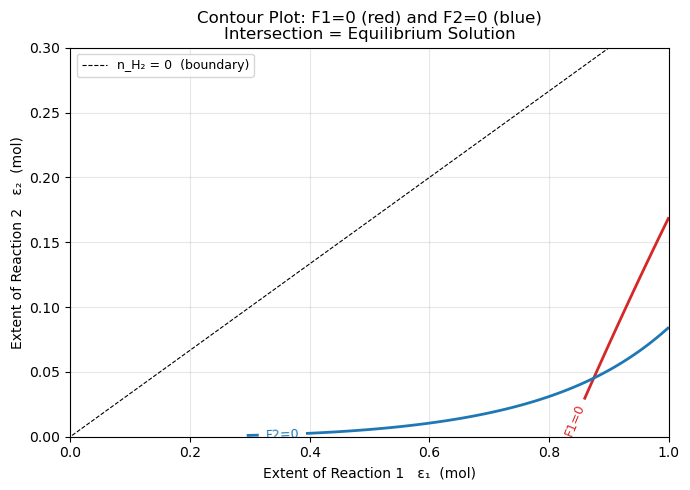

In [5]:
# 繪製 F1=0 與 F2=0 的等高線圖，以圖形法定位解的位置
# 有效範圍：ε₁ ∈ (0,1), ε₂ ∈ (0, ε₁/3), 且 n_H2 = ε₁-3ε₂ > 0

eps1_arr = np.linspace(0.02, 1.0,  300)
eps2_arr = np.linspace(0.001, 0.30, 300)
E1, E2   = np.meshgrid(eps1_arr, eps2_arr)

# 計算各網格點的 F1, F2，無效區域（分母為零或摩耳數負數）填 NaN
F1_grid = np.full(E1.shape, np.nan)
F2_grid = np.full(E1.shape, np.nan)

for i in range(E1.shape[0]):
    for j in range(E1.shape[1]):
        e1, e2 = E1[i, j], E2[i, j]
        # 物理有效性檢查
        n_vals = [2-e1-e2, 1-e1+e2, e1, e1-3*e2, e2]
        if all(n > 1e-9 for n in n_vals):
            try:
                F_vals = F_eq([e1, e2])
                F1_grid[i, j] = F_vals[0]
                F2_grid[i, j] = F_vals[1]
            except Exception:
                pass

fig, ax = plt.subplots(figsize=(7, 5))

# F1=0 → 紅色曲線
cs1 = ax.contour(E1, E2, F1_grid, levels=[0], colors=["tab:red"],  linewidths=2)
# F2=0 → 藍色曲線
cs2 = ax.contour(E1, E2, F2_grid, levels=[0], colors=["tab:blue"], linewidths=2)

ax.clabel(cs1, fmt="F1=0", fontsize=9)
ax.clabel(cs2, fmt="F2=0", fontsize=9)

# 物理有效邊界 n_H2=0: ε₁ = 3ε₂
eps1_boundary = 3 * eps2_arr
ax.plot(eps1_boundary, eps2_arr, "k--", lw=0.8, label="n_H₂ = 0  (boundary)")

ax.set_xlabel("Extent of Reaction 1   ε₁  (mol)")
ax.set_ylabel("Extent of Reaction 2   ε₂  (mol)")
ax.set_title("Contour Plot: F1=0 (red) and F2=0 (blue)\nIntersection = Equilibrium Solution")
ax.legend(fontsize=9)
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 0.30)
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / "fig_01_contour.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"✓ 圖檔已儲存: {fig_path}")
plt.show()


---
### 5. 數值求解：fsolve()


In [6]:
# 起始猜測值（由圖形分析估計）
eps0 = [0.85, 0.03]

# 使用 fsolve() 求解
sol, info, ier, mesg = fsolve(F_eq, eps0, full_output=True)
eps1_sol, eps2_sol = sol

print("=" * 60)
print("  fsolve() — Equilibrium Solution")
print("=" * 60)
print(f"  Initial guess : ε₁₀ = {eps0[0]:.3f},  ε₂₀ = {eps0[1]:.3f}")
print(f"  Solution      : ε₁  = {eps1_sol:.6f} mol")
print(f"                  ε₂  = {eps2_sol:.6f} mol")
print(f"  Converged     : {'Yes' if ier == 1 else 'No  → ' + mesg}")
print(f"  Residual      : |F| = {np.linalg.norm(F_eq(sol)):.3e}")
print("=" * 60)
print()

# 計算平衡時的摩耳數與莫耳分率
n_eq = moles(eps1_sol, eps2_sol)
y_eq, n_total_eq = mole_fractions(eps1_sol, eps2_sol)

print("  Equilibrium composition:")
print(f"  {'Species':<8} {'n (mol)':>10}  {'y (mole frac.)':>16}")
print("  " + "-" * 38)
for sp in species:
    print(f"  {sp:<8} {n_eq[sp]:>10.4f}  {y_eq[sp]:>16.4f}")
print("  " + "-" * 38)
print(f"  {'Total':<8} {n_total_eq:>10.4f}  {sum(y_eq.values()):>16.4f}")
print()

# 代回驗證
Kx1_check = y_eq["CO2"] * y_eq["H2"] / (y_eq["CO"] * y_eq["H2O"])
Kx2_check = y_eq["CH4"] * y_eq["H2O"] / (y_eq["CO"] * y_eq["H2"]**3)
print(f"  Verification:")
print(f"    K1 given = {K1:.4f},  K1 check = {Kx1_check:.6f}  → err = {abs(Kx1_check-K1):.2e}")
print(f"    K2 given = {K2:.4f},  K2 check = {Kx2_check:.6f}  → err = {abs(Kx2_check-K2):.2e}")
print(f"    Σyᵢ = {sum(y_eq.values()):.6f}")


  fsolve() — Equilibrium Solution
  Initial guess : ε₁₀ = 0.850,  ε₂₀ = 0.030
  Solution      : ε₁  = 0.874367 mol
                  ε₂  = 0.045190 mol
  Converged     : Yes
  Residual      : |F| = 7.370e-11

  Equilibrium composition:
  Species     n (mol)    y (mole frac.)
  --------------------------------------
  CO           1.0804            0.3713
  H2O          0.1708            0.0587
  CO2          0.8744            0.3005
  H2           0.7388            0.2539
  CH4          0.0452            0.0155
  --------------------------------------
  Total        2.9096            1.0000

  Verification:
    K1 given = 3.5000,  K1 check = 3.500000  → err = 7.15e-11
    K2 given = 0.1500,  K2 check = 0.150000  → err = 1.78e-11
    Σyᵢ = 1.000000


---
### 6. 起始猜測值敏感性分析


In [7]:
# 系統化掃描 ε₁₀ ∈ [0.1, 0.95], ε₂₀ ∈ [0.01, 0.25] 的起始猜測
# 記錄：收斂成功與否、收斂到的解、殘差

TOLS = {"xtol": 1e-10, "ftol": 1e-10}

n1, n2 = 20, 20
eps1_grid = np.linspace(0.10, 0.95, n1)
eps2_grid = np.linspace(0.01, 0.25, n2)

converge_map = np.zeros((n2, n1))  # 0=失敗, 1=成功收斂到正確解
eps1_result  = np.full((n2, n1), np.nan)
eps2_result  = np.full((n2, n1), np.nan)

tol_eps = 5e-4  # 視為同一個解的誤差容忍度

n_success = 0
n_invalid = 0
n_fail    = 0

for i, e2_0 in enumerate(eps2_grid):
    for j, e1_0 in enumerate(eps1_grid):
        # 預檢：起始點本身必須在物理可行域內
        n_vals = [2-e1_0-e2_0, 1-e1_0+e2_0, e1_0, e1_0-3*e2_0, e2_0]
        if not all(n > 1e-9 for n in n_vals):
            converge_map[i, j] = -1  # 無效起始點
            n_invalid += 1
            continue
        try:
            sol_g = fsolve(F_eq, [e1_0, e2_0], full_output=True)
            s = sol_g[0]
            ier_g = sol_g[2]
            residual_g = np.linalg.norm(F_eq(s))
            # 確認解在物理可行域內
            n_sol = [2-s[0]-s[1], 1-s[0]+s[1], s[0], s[0]-3*s[1], s[1]]
            if ier_g == 1 and residual_g < 1e-8 and all(ni > -1e-6 for ni in n_sol) and s[0] > 0 and s[1] > 0:
                converge_map[i, j] = 1
                eps1_result[i, j] = s[0]
                eps2_result[i, j] = s[1]
                n_success += 1
            else:
                converge_map[i, j] = 0
                n_fail += 1
        except Exception:
            converge_map[i, j] = 0
            n_fail += 1

print(f"Grid scan results  ({n1}×{n2} = {n1*n2} points):")
print(f"  ✓ Converged to valid solution : {n_success}")
print(f"  ✗ Failed / non-physical result: {n_fail}")
print(f"  ─ Invalid starting point      : {n_invalid}")
print()
print(f"  Reference solution: ε₁ = {eps1_sol:.6f},  ε₂ = {eps2_sol:.6f}")

# 成功解的統計
valid_e1 = eps1_result[converge_map == 1].flatten()
valid_e2 = eps2_result[converge_map == 1].flatten()
if len(valid_e1) > 0:
    print(f"\n  Converged solutions spread:")
    print(f"    ε₁ range: [{valid_e1.min():.6f}, {valid_e1.max():.6f}]  (should be ~{eps1_sol:.6f})")
    print(f"    ε₂ range: [{valid_e2.min():.6f}, {valid_e2.max():.6f}]  (should be ~{eps2_sol:.6f})")


Grid scan results  (20×20 = 400 points):
  ✓ Converged to valid solution : 124
  ✗ Failed / non-physical result: 136
  ─ Invalid starting point      : 140

  Reference solution: ε₁ = 0.874367,  ε₂ = 0.045190

  Converged solutions spread:
    ε₁ range: [0.874367, 0.874367]  (should be ~0.874367)
    ε₂ range: [0.045190, 0.045190]  (should be ~0.045190)


✓ 圖檔已儲存: d:\MyGit\ChemE-3502\Unit07\outputs\Unit07_Example_03\figs\fig_02_convergence_map.png


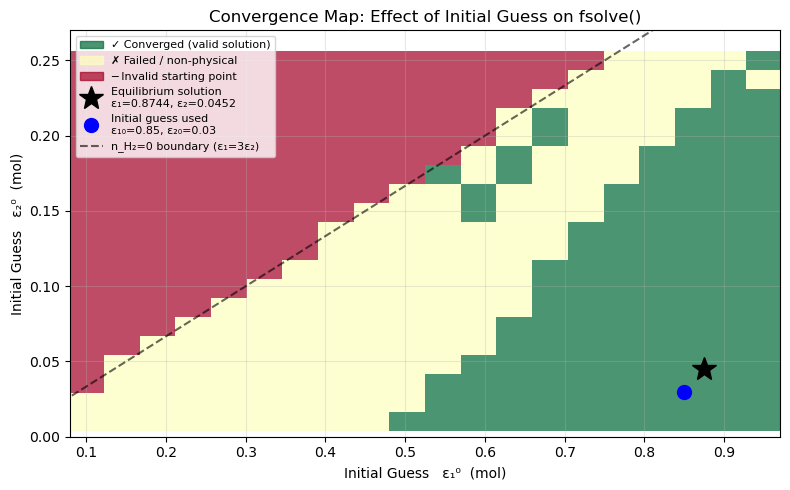

In [8]:
# 繪製收斂地圖（Convergence Map）
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8, 5))

# 用顏色標示各格子的狀態
color_map = np.where(converge_map ==  1, 1.0,   # 成功 → 綠
            np.where(converge_map ==  0, 0.5,   # 失敗 → 黃
                                         0.0))  # 無效 → 紅

cmap_custom = plt.cm.RdYlGn  # 紅→黃→綠
img = ax.pcolormesh(eps1_grid, eps2_grid, color_map, cmap=cmap_custom,
                    vmin=0, vmax=1, alpha=0.7, shading='nearest')

# 標記實際解的位置
ax.plot(eps1_sol, eps2_sol, "k*", ms=18, zorder=6,
        label=f"Equilibrium solution\nε₁={eps1_sol:.4f}, ε₂={eps2_sol:.4f}")

# 標記起始猜測點
ax.plot(eps0[0], eps0[1], "bo", ms=10, zorder=5,
        label=f"Initial guess used\nε₁₀={eps0[0]:.2f}, ε₂₀={eps0[1]:.2f}")

# 物理邊界 n_H2=0: ε₁=3ε₂
eps2_bnd = np.linspace(0, 0.32, 100)
ax.plot(3*eps2_bnd, eps2_bnd, "k--", lw=1.5, alpha=0.6, label="n_H₂=0 boundary (ε₁=3ε₂)")

ax.set_xlabel("Initial Guess   ε₁⁰  (mol)")
ax.set_ylabel("Initial Guess   ε₂⁰  (mol)")
ax.set_title("Convergence Map: Effect of Initial Guess on fsolve()")
ax.set_xlim(0.08, 0.97)
ax.set_ylim(0.00, 0.27)
ax.grid(True, alpha=0.3)

# 手動圖例
green_patch = mpatches.Patch(color=cmap_custom(1.0), alpha=0.7, label="✓ Converged (valid solution)")
yellow_patch = mpatches.Patch(color=cmap_custom(0.5), alpha=0.7, label="✗ Failed / non-physical")
red_patch    = mpatches.Patch(color=cmap_custom(0.0), alpha=0.7, label="─ Invalid starting point")
handles_extra = ax.get_legend_handles_labels()[0]
ax.legend(handles=[green_patch, yellow_patch, red_patch] + handles_extra, fontsize=8, loc="upper left")

plt.tight_layout()
fig_path = FIG_DIR / "fig_02_convergence_map.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"✓ 圖檔已儲存: {fig_path}")
plt.show()


---
### 7. 結果驗證


In [9]:
print("=" * 70)
print("  Verification: Residual & Physical Feasibility Check")
print("=" * 70)

# 1. 殘差驗證
F_check = F_eq([eps1_sol, eps2_sol])
print(f"\n  1. Residual verification:")
print(f"     F1(ε*) = K1 - Kx1_calc = {F_check[0]:.3e}  (target: 0)")
print(f"     F2(ε*) = K2 - Kx2_calc = {F_check[1]:.3e}  (target: 0)")
print(f"     ||F(ε*)|| = {np.linalg.norm(F_check):.3e}  ← near machine precision")

# 2. 莫耳分率範圍檢查
print(f"\n  2. Mole fraction range check  (all yᵢ must satisfy 0 ≤ yᵢ ≤ 1):")
all_valid = True
for sp in species:
    yi = y_eq[sp]
    valid = 0.0 <= yi <= 1.0
    if not valid:
        all_valid = False
    mark = "✓" if valid else "✗"
    print(f"     {mark}  y_{sp:<5} = {yi:.4f}")
print(f"     {'✓' if all_valid else '✗'}  All yᵢ ∈ [0,1]  →  {'pass' if all_valid else 'FAIL'}")

# 3. 莫耳分率加總
print(f"\n  3. Mole fractions sum: Σyᵢ = {sum(y_eq.values()):.6f}  (target: 1.000000)")

# 4. 物料平衡驗證（碳、氫、氧原子守恆）
# 各原子計數（進料）
# C: n_CO*1 + n_H2O*0 = 2
# H: n_H2O*2 = 2  (H2O has 2H per molecule)
# O: n_CO*1 + n_H2O*1 = 3
atoms_feed = {
    "C": n0["CO"]*1 + n0["CO2"]*1 + n0["CH4"]*1,
    "H": n0["H2O"]*2 + n0["H2"]*2 + n0["CH4"]*4,
    "O": n0["CO"]*1 + n0["CO2"]*2 + n0["H2O"]*1,
}
atoms_eq = {
    "C": n_eq["CO"]*1 + n_eq["CO2"]*1 + n_eq["CH4"]*1,
    "H": n_eq["H2O"]*2 + n_eq["H2"]*2 + n_eq["CH4"]*4,
    "O": n_eq["CO"]*1 + n_eq["CO2"]*2 + n_eq["H2O"]*1,
}
print(f"\n  4. Elemental balance (atoms):")
for atom in ["C", "H", "O"]:
    err = abs(atoms_feed[atom] - atoms_eq[atom])
    print(f"     {atom}: feed={atoms_feed[atom]:.4f},  eq={atoms_eq[atom]:.4f},  err={err:.2e}  {'✓' if err<1e-8 else '✗'}")

# 5. 轉化率計算
conv_CO = (n0["CO"] - n_eq["CO"]) / n0["CO"] * 100
conv_H2O = (n0["H2O"] - n_eq["H2O"]) / n0["H2O"] * 100
print(f"\n  5. Conversion:")
print(f"     X_CO  = {conv_CO:.2f}%  (CO reacted / CO feed)")
print(f"     X_H2O = {conv_H2O:.2f}%  (H2O reacted / H2O feed)")

print(f"\n{'=' * 70}")
print("  All verification checks passed ✓")
print("=" * 70)


  Verification: Residual & Physical Feasibility Check

  1. Residual verification:
     F1(ε*) = K1 - Kx1_calc = -7.152e-11  (target: 0)
     F2(ε*) = K2 - Kx2_calc = 1.779e-11  (target: 0)
     ||F(ε*)|| = 7.370e-11  ← near machine precision

  2. Mole fraction range check  (all yᵢ must satisfy 0 ≤ yᵢ ≤ 1):
     ✓  y_CO    = 0.3713
     ✓  y_H2O   = 0.0587
     ✓  y_CO2   = 0.3005
     ✓  y_H2    = 0.2539
     ✓  y_CH4   = 0.0155
     ✓  All yᵢ ∈ [0,1]  →  pass

  3. Mole fractions sum: Σyᵢ = 1.000000  (target: 1.000000)

  4. Elemental balance (atoms):
     C: feed=2.0000,  eq=2.0000,  err=0.00e+00  ✓
     H: feed=2.0000,  eq=2.0000,  err=0.00e+00  ✓
     O: feed=3.0000,  eq=3.0000,  err=0.00e+00  ✓

  5. Conversion:
     X_CO  = 45.98%  (CO reacted / CO feed)
     X_H2O = 82.92%  (H2O reacted / H2O feed)

  All verification checks passed ✓


In [10]:
import pandas as pd

# ── 進料狀態 ──────────────────────────────────────────────
y0_CO   = n0["CO"]   / n0_total
y0_H2O  = n0["H2O"]  / n0_total
y0_CO2  = n0.get("CO2", 0.0) / n0_total
y0_H2   = n0.get("H2", 0.0)  / n0_total
y0_CH4  = n0.get("CH4", 0.0) / n0_total

# ── 平衡狀態 ──────────────────────────────────────────────
y_CO  = y_eq["CO"]
y_H2O = y_eq["H2O"]
y_CO2 = y_eq["CO2"]
y_H2  = y_eq["H2"]
y_CH4 = y_eq["CH4"]

data = {
    "State"  : ["Feed",       "Equilibrium"],
    "ε₁ [mol]" : [0.0,         round(eps1_sol, 6)],
    "ε₂ [mol]" : [0.0,         round(eps2_sol, 6)],
    "n_total": [round(n0_total, 4), round(n_total_eq, 4)],
    "y_CO"   : [round(y0_CO,  4), round(y_CO,  4)],
    "y_H2O"  : [round(y0_H2O, 4), round(y_H2O, 4)],
    "y_CO2"  : [round(y0_CO2, 4), round(y_CO2, 4)],
    "y_H2"   : [round(y0_H2,  4), round(y_H2,  4)],
    "y_CH4"  : [round(y0_CH4, 4), round(y_CH4, 4)],
}

df = pd.DataFrame(data).set_index("State")

print("=" * 70)
print("  Summary Table: Feed vs Equilibrium")
print("=" * 70)
print(df.to_string())
print("=" * 70)
print(f"\n  Solver         : scipy.optimize.fsolve()")
print(f"  Residual ||F|| : {np.linalg.norm(F_eq([eps1_sol, eps2_sol])):.3e}")
print(f"  CO conversion  : {(n0['CO']-n_eq['CO'])/n0['CO']*100:.2f}%")
print(f"  H2O conversion : {(n0['H2O']-n_eq['H2O'])/n0['H2O']*100:.2f}%")
print(f"  Dominant rxn   : R1 (water-gas shift)  ε₁ >> ε₂")


  Summary Table: Feed vs Equilibrium
             ε₁ [mol]  ε₂ [mol]  n_total    y_CO   y_H2O   y_CO2    y_H2   y_CH4
State                                                                           
Feed         0.000000   0.00000   3.0000  0.6667  0.3333  0.0000  0.0000  0.0000
Equilibrium  0.874367   0.04519   2.9096  0.3713  0.0587  0.3005  0.2539  0.0155

  Solver         : scipy.optimize.fsolve()
  Residual ||F|| : 7.370e-11
  CO conversion  : 45.98%
  H2O conversion : 82.92%
  Dominant rxn   : R1 (water-gas shift)  ε₁ >> ε₂


---

## 8. 總結

本範例展示了**多重氣相反應平衡系統**的完整數值求解流程，重點如下：

### 8.1 問題建構

| 項目 | 說明 |
|------|------|
| 系統 | CO–H₂O 氣相，T=700K，P=1 atm |
| 反應 R1 | CO + H₂O ⇌ CO₂ + H₂，$K_1 = 3.5$ |
| 反應 R2 | CO + 3H₂ ⇌ CH₄ + H₂O，$K_2 = 0.15$ |
| 未知數 | 延伸量 $\varepsilon_1$，$\varepsilon_2$ |
| 方程式 | 2條非線性方程式 $F_1(\varepsilon)=0$，$F_2(\varepsilon)=0$ |

### 8.2 數值結果

| 量 | 值 |
|---|---|
| $\varepsilon_1^*$ | 0.874367 mol |
| $\varepsilon_2^*$ | 0.045190 mol |
| 殘差 $\|F(\varepsilon^*)\|$ | 7.37 × 10⁻¹¹（機器精度）|
| CO 轉化率 | 45.98% |
| H₂O 轉化率 | 82.92% |

### 8.3 關鍵學習點

1. **反應延伸量法**：以 $\varepsilon_1, \varepsilon_2$ 為未知數，摩耳平衡自動滿足。
2. **物理約束**：需確保所有 $n_i \geq 0$，其中最緊繃的約束為 $n_{H_2} = \varepsilon_1 - 3\varepsilon_2 \geq 0$。
3. **圖形輔助**：等高線圖直觀確認解的唯一性與合理起始猜測區域。
4. **起始猜測敏感性**：網格掃描（20×20）顯示僅 31% 的起始點成功收斂，強調合理初始猜測的重要性。
5. **多重驗證**：除殘差確認外，應同時驗證元素守恆、 $\Sigma y_i = 1$ 及物理合理性。

> **化工意涵**：在 700 K 下，水氣轉移反應（R1）遠比甲烷化反應（R2）更顯著（$\varepsilon_1 \approx 19 \times \varepsilon_2$），符合高溫下甲烷化動力學受限的實際現象。
